<a href="https://colab.research.google.com/github/DavidPonceArauz/Lifexp/blob/main/Modelo_Isolation_Forest_Cooperativa_Ecuador_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo contextual de anomalías con Isolation Forest

Este cuaderno utiliza la misma base:

`Base_Comparativa_Falsos_Positivos_Negativos_IF_vs_IA.xlsx`

El modelo:

1. Aprende exclusivamente de las operaciones del periodo `HISTORICO`.
2. Construye variables relativas al comportamiento de cada socio.
3. Ejecuta Isolation Forest.
4. Marca como alertas las operaciones con puntaje superior al percentil 95 del historial.
5. Explica el contexto que hace inusual cada alerta.
6. Valida los resultados con `Control_Verdad`.
7. Descarga un Excel con los resultados.

> Isolation Forest es un modelo no supervisado. No afirma que exista fraude; identifica patrones estadísticamente atípicos que deben ser revisados por una persona.


## Variables contextuales utilizadas

| Variable | Interpretación |
|---|---|
| `Relacion_Promedio` | Monto actual dividido para el promedio histórico del socio |
| `Relacion_Dia` | Monto actual comparado con el promedio del mismo día de la semana |
| `Z_Robusto` | Distancia del monto respecto a la mediana histórica usando MAD |
| `Desviacion_Hora` | Distancia respecto al horario habitual del socio |
| `Relacion_Frecuencia` | Operaciones actuales en 60 minutos respecto al máximo histórico |
| `Novedad_Canal` | Rareza del canal según su frecuencia histórica |

La explicación mostrada para cada alerta es una interpretación contextual de estas variables. No es una atribución causal exacta del algoritmo.


## Paso 1. Importar las herramientas


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)

print("Herramientas cargadas correctamente.")


Herramientas cargadas correctamente.


## Paso 2. Subir la base de datos


In [2]:
archivos = files.upload()

if not archivos:
    raise ValueError("No se cargó ningún archivo.")

nombre_archivo = next(iter(archivos))

print("Archivo cargado:", nombre_archivo)


Saving Base_Comparativa_Falsos_Positivos_Negativos_IF_vs_IA.xlsx to Base_Comparativa_Falsos_Positivos_Negativos_IF_vs_IA.xlsx
Archivo cargado: Base_Comparativa_Falsos_Positivos_Negativos_IF_vs_IA.xlsx


## Paso 3. Leer y validar `Base_Transacciones`


In [3]:
datos = pd.read_excel(
    nombre_archivo,
    sheet_name="Base_Transacciones"
)

columnas_requeridas = [
    "ID_Transaccion",
    "Codigo_Socio",
    "Fecha_Hora",
    "Tipo_Operacion",
    "Monto_USD",
    "Canal",
    "Agencia",
    "Saldo_Posterior_USD",
    "Periodo"
]

faltantes = [
    columna for columna in columnas_requeridas
    if columna not in datos.columns
]

if faltantes:
    raise ValueError(
        "La base no contiene las columnas requeridas: "
        + ", ".join(faltantes)
    )

datos["Fecha_Hora"] = pd.to_datetime(
    datos["Fecha_Hora"],
    errors="coerce"
)

datos["Monto_USD"] = pd.to_numeric(
    datos["Monto_USD"],
    errors="coerce"
)

datos = datos.sort_values(
    ["Codigo_Socio", "Fecha_Hora"]
).reset_index(drop=True)

print("Registros:", len(datos))
print("Fechas inválidas:", datos["Fecha_Hora"].isna().sum())
print("Montos inválidos:", datos["Monto_USD"].isna().sum())
print("Duplicados por ID:", datos["ID_Transaccion"].duplicated().sum())

display(datos["Periodo"].value_counts().rename("Cantidad").to_frame())
display(datos.head())


Registros: 7641
Fechas inválidas: 0
Montos inválidos: 0
Duplicados por ID: 0


,Cantidad
Periodo,
HISTORICO,5800
EVALUACION,1841


,ID_Transaccion,Codigo_Socio,Fecha_Hora,Tipo_Operacion,Monto_USD,Canal,Agencia,Saldo_Posterior_USD,Periodo
0,T00014,S001,2026-01-02 17:00:00,Depósito,202.56,App móvil,Digital,3658.71,HISTORICO
1,T00054,S001,2026-01-03 08:38:00,Retiro,174.22,App móvil,Digital,21.87,HISTORICO
2,T00035,S001,2026-01-06 17:19:00,Transferencia,190.27,App móvil,Digital,1745.66,HISTORICO
3,T00050,S001,2026-01-06 18:08:00,Pago de crédito,172.12,App móvil,Digital,114.48,HISTORICO
4,T00047,S001,2026-01-07 12:32:00,Retiro,158.21,App móvil,Digital,644.68,HISTORICO


## Paso 4. Crear variables temporales y frecuencia de 60 minutos


In [4]:
datos["Hora_Num"] = datos["Fecha_Hora"].dt.hour
datos["Dia_Semana"] = datos["Fecha_Hora"].dt.weekday


def contar_operaciones_60_minutos(serie_fechas):
    fechas = serie_fechas.tolist()
    cantidades = []
    izquierda = 0

    for derecha, fecha_actual in enumerate(fechas):
        limite = fecha_actual - pd.Timedelta(minutes=60)

        while (
            izquierda < derecha
            and fechas[izquierda] < limite
        ):
            izquierda += 1

        cantidades.append(derecha - izquierda + 1)

    return pd.Series(
        cantidades,
        index=serie_fechas.index
    )


datos["Operaciones_60_Min"] = (
    datos
    .groupby(
        "Codigo_Socio",
        group_keys=False
    )["Fecha_Hora"]
    .apply(contar_operaciones_60_minutos)
)

historico = datos[
    datos["Periodo"].str.upper() == "HISTORICO"
].copy()

evaluacion_base = datos[
    datos["Periodo"].str.upper() == "EVALUACION"
].copy()

if historico.empty or evaluacion_base.empty:
    raise ValueError(
        "La base debe contener registros HISTORICO y EVALUACION."
    )

print("Registros históricos:", len(historico))
print("Registros de evaluación:", len(evaluacion_base))


Registros históricos: 5800
Registros de evaluación: 1841


## Paso 5. Calcular el comportamiento histórico de cada socio


In [5]:
estadisticas_monto = (
    historico
    .groupby("Codigo_Socio")["Monto_USD"]
    .agg(
        Promedio_Historico="mean",
        Mediana_Historica="median"
    )
    .reset_index()
)


mad_monto = (
    historico
    .groupby("Codigo_Socio")["Monto_USD"]
    .apply(
        lambda serie:
        np.median(
            np.abs(
                serie - np.median(serie)
            )
        )
    )
    .rename("MAD_Historico")
    .reset_index()
)


promedio_dia = (
    historico
    .groupby(
        [
            "Codigo_Socio",
            "Dia_Semana"
        ]
    )["Monto_USD"]
    .mean()
    .rename("Promedio_Dia")
    .reset_index()
)


hora_mediana = (
    historico
    .groupby("Codigo_Socio")["Hora_Num"]
    .median()
    .rename("Hora_Mediana")
    .reset_index()
)


mad_hora = (
    historico
    .groupby("Codigo_Socio")["Hora_Num"]
    .apply(
        lambda serie:
        np.median(
            np.abs(
                serie - np.median(serie)
            )
        )
    )
    .rename("MAD_Hora")
    .reset_index()
)


max_frecuencia = (
    historico
    .groupby("Codigo_Socio")[
        "Operaciones_60_Min"
    ]
    .max()
    .rename("Max_Operaciones_60")
    .reset_index()
)


frecuencia_canal = (
    historico
    .groupby(
        [
            "Codigo_Socio",
            "Canal"
        ]
    )
    .size()
    .rename("Cantidad_Canal")
    .reset_index()
)


total_historico = (
    historico
    .groupby("Codigo_Socio")
    .size()
    .rename("Total_Historico")
    .reset_index()
)


frecuencia_canal = frecuencia_canal.merge(
    total_historico,
    on="Codigo_Socio",
    how="left"
)

frecuencia_canal["Frecuencia_Canal"] = (
    frecuencia_canal["Cantidad_Canal"]
    / frecuencia_canal["Total_Historico"]
)

print("Referencias históricas calculadas.")


Referencias históricas calculadas.


## Paso 6. Construir las variables contextuales


In [7]:
datos_modelo = (
    datos
    .merge(
        estadisticas_monto,
        on="Codigo_Socio",
        how="left"
    )
    .merge(
        mad_monto,
        on="Codigo_Socio",
        how="left"
    )
    .merge(
        promedio_dia,
        on=[
            "Codigo_Socio",
            "Dia_Semana"
        ],
        how="left"
    )
    .merge(
        hora_mediana,
        on="Codigo_Socio",
        how="left"
    )
    .merge(
        mad_hora,
        on="Codigo_Socio",
        how="left"
    )
    .merge(
        max_frecuencia,
        on="Codigo_Socio",
        how="left"
    )
    .merge(
        frecuencia_canal[
            [
                "Codigo_Socio",
                "Canal",
                "Frecuencia_Canal"
            ]
        ],
        on=[
            "Codigo_Socio",
            "Canal"
        ],
        how="left"
    )
)

datos_modelo["Promedio_Dia"] = (
    datos_modelo["Promedio_Dia"]
    .fillna(
        datos_modelo["Promedio_Historico"]
    )
)

datos_modelo["Frecuencia_Canal"] = (
    datos_modelo["Frecuencia_Canal"]
    .fillna(0)
)


datos_modelo["Relacion_Promedio"] = (
    datos_modelo["Monto_USD"]
    / datos_modelo["Promedio_Historico"]
)


datos_modelo["Relacion_Dia"] = (
    datos_modelo["Monto_USD"]
    / datos_modelo["Promedio_Dia"]
)


datos_modelo["Z_Robusto"] = (
    np.abs(
        datos_modelo["Monto_USD"]
        - datos_modelo["Mediana_Historica"]
    )
    /
    (
        1.4826
        * datos_modelo["MAD_Historico"]
        .clip(lower=1)
    )
)


distancia_hora = np.minimum(
    np.abs(
        datos_modelo["Hora_Num"]
        - datos_modelo["Hora_Mediana"]
    ),
    24 - np.abs(
        datos_modelo["Hora_Num"]
        - datos_modelo["Hora_Mediana"]
    )
)


datos_modelo["Desviacion_Hora"] = (
    distancia_hora
    /
    (
        datos_modelo["MAD_Hora"]
        .clip(lower=1)
        + 1
    )
)


datos_modelo["Relacion_Frecuencia"] = (
    datos_modelo["Operaciones_60_Min"]
    / datos_modelo["Max_Operaciones_60"]
    .clip(lower=1)
)


datos_modelo["Novedad_Canal"] = (
    1 - datos_modelo["Frecuencia_Canal"]
)

print("Variables contextuales construidas.")


Variables contextuales construidas.


## Paso 7. Entrenar Isolation Forest y calcular el umbral


In [8]:
variables_ia = [
    "Relacion_Promedio",
    "Relacion_Dia",
    "Z_Robusto",
    "Desviacion_Hora",
    "Relacion_Frecuencia",
    "Novedad_Canal"
]


X_train = (
    datos_modelo.loc[
        datos_modelo["Periodo"].str.upper()
        == "HISTORICO",
        variables_ia
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .fillna(0)
)


X_eval = (
    datos_modelo.loc[
        datos_modelo["Periodo"].str.upper()
        == "EVALUACION",
        variables_ia
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .fillna(0)
)


modelo = IsolationForest(
    n_estimators=500,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train)


puntaje_historico = (
    -modelo.score_samples(X_train)
)


# Umbral definido exclusivamente con el historial.
# El percentil 95 significa que se alerta el 5 % más atípico
# respecto al patrón histórico aprendido.
umbral_ia = float(
    np.quantile(
        puntaje_historico,
        0.95
    )
)


puntaje_evaluacion = (
    -modelo.score_samples(X_eval)
)


evaluacion_ia = (
    datos_modelo[
        datos_modelo["Periodo"].str.upper()
        == "EVALUACION"
    ]
    .copy()
)


evaluacion_ia["Puntaje_IA"] = (
    puntaje_evaluacion
)


evaluacion_ia["Alerta_Isolation_Forest"] = (
    evaluacion_ia["Puntaje_IA"]
    > umbral_ia
)

print("Modelo entrenado correctamente.")
print("Umbral IA:", round(umbral_ia, 6))


Modelo entrenado correctamente.
Umbral IA: 0.561137


## Paso 8. Crear una explicación contextual para cada alerta


In [9]:
def explicar_alerta_ia(fila):
    razones = []

    if fila["Relacion_Promedio"] >= 1.50:
        razones.append(
            f"monto equivalente a "
            f"{fila['Relacion_Promedio']:.2f} veces "
            "el promedio histórico"
        )

    if fila["Z_Robusto"] >= 3:
        razones.append(
            f"monto alejado de la mediana histórica "
            f"(desviación robusta {fila['Z_Robusto']:.2f})"
        )

    if fila["Relacion_Dia"] >= 1.50:
        razones.append(
            f"monto {fila['Relacion_Dia']:.2f} veces "
            "superior al patrón del mismo día de la semana"
        )

    if fila["Desviacion_Hora"] >= 2.50:
        razones.append(
            "horario distante del patrón habitual del socio"
        )

    if fila["Relacion_Frecuencia"] > 1:
        razones.append(
            f"frecuencia de 60 minutos "
            f"{fila['Relacion_Frecuencia']:.2f} veces "
            "superior al máximo histórico"
        )

    if fila["Frecuencia_Canal"] == 0:
        razones.append(
            f"canal no observado en el historial: "
            f"{fila['Canal']}"
        )
    elif fila["Novedad_Canal"] >= 0.90:
        razones.append(
            f"canal de uso muy poco frecuente: "
            f"{fila['Canal']}"
        )

    if not razones:
        razones.append(
            "combinación global inusual de monto, "
            "horario, frecuencia y canal"
        )

    return "; ".join(razones)


evaluacion_ia["Por_Que_Isolation_Forest"] = (
    evaluacion_ia.apply(
        explicar_alerta_ia,
        axis=1
    )
)


def clasificar_rareza(puntaje):
    exceso = puntaje - umbral_ia

    if exceso >= 0.12:
        return "Alta"
    if exceso >= 0.05:
        return "Media"
    if puntaje > umbral_ia:
        return "Baja"
    return "Normal"


evaluacion_ia["Nivel_Rareza_IA"] = (
    evaluacion_ia["Puntaje_IA"]
    .apply(clasificar_rareza)
)

print("Explicaciones contextuales creadas.")


Explicaciones contextuales creadas.


## Paso 9. Mostrar cuántas alertas detectó el modelo y por qué


In [10]:
alertas_ia = (
    evaluacion_ia[
        evaluacion_ia[
            "Alerta_Isolation_Forest"
        ]
    ]
    .copy()
)

print("=" * 70)
print("RESULTADO DE ISOLATION FOREST")
print("=" * 70)
print("Operaciones evaluadas:", len(evaluacion_ia))
print("Alertas generadas:", len(alertas_ia))
print(
    "Porcentaje alertado:",
    f"{len(alertas_ia) / len(evaluacion_ia):.2%}"
)
print("Umbral de rareza:", round(umbral_ia, 6))

print("\nAlertas por nivel:")
display(
    alertas_ia[
        "Nivel_Rareza_IA"
    ]
    .value_counts()
    .rename("Cantidad")
    .to_frame()
)


def contar_motivo(texto, fragmento):
    return texto.str.contains(
        fragmento,
        case=False,
        na=False
    ).sum()


resumen_motivos_ia = pd.DataFrame({
    "Motivo_Contextual": [
        "Monto alto respecto al promedio",
        "Monto alejado de la mediana",
        "Monto atípico para el día",
        "Horario distante del patrón",
        "Frecuencia superior al historial",
        "Canal nuevo o muy poco frecuente",
        "Combinación global inusual"
    ],
    "Cantidad": [
        int(contar_motivo(
            alertas_ia["Por_Que_Isolation_Forest"],
            "veces el promedio"
        )),
        int(contar_motivo(
            alertas_ia["Por_Que_Isolation_Forest"],
            "mediana histórica"
        )),
        int(contar_motivo(
            alertas_ia["Por_Que_Isolation_Forest"],
            "mismo día"
        )),
        int(contar_motivo(
            alertas_ia["Por_Que_Isolation_Forest"],
            "horario distante"
        )),
        int(contar_motivo(
            alertas_ia["Por_Que_Isolation_Forest"],
            "máximo histórico"
        )),
        int(
            contar_motivo(
                alertas_ia["Por_Que_Isolation_Forest"],
                "canal no observado"
            )
            + contar_motivo(
                alertas_ia["Por_Que_Isolation_Forest"],
                "poco frecuente"
            )
        ),
        int(contar_motivo(
            alertas_ia["Por_Que_Isolation_Forest"],
            "combinación global"
        ))
    ]
})

print("\nResumen de explicaciones:")
display(resumen_motivos_ia)

columnas_alerta = [
    "ID_Transaccion",
    "Codigo_Socio",
    "Fecha_Hora",
    "Tipo_Operacion",
    "Monto_USD",
    "Canal",
    "Agencia",
    "Operaciones_60_Min",
    "Puntaje_IA",
    "Nivel_Rareza_IA",
    "Relacion_Promedio",
    "Relacion_Dia",
    "Z_Robusto",
    "Desviacion_Hora",
    "Relacion_Frecuencia",
    "Novedad_Canal",
    "Por_Que_Isolation_Forest"
]

display(
    alertas_ia[
        columnas_alerta
    ]
    .sort_values(
        "Puntaje_IA",
        ascending=False
    )
    .head(50)
)


RESULTADO DE ISOLATION FOREST
Operaciones evaluadas: 1841
Alertas generadas: 191
Porcentaje alertado: 10.37%
Umbral de rareza: 0.561137

Alertas por nivel:


,Cantidad
Nivel_Rareza_IA,
Baja,99
Media,68
Alta,24



Resumen de explicaciones:


,Motivo_Contextual,Cantidad
0,Monto alto respecto al promedio,94
1,Monto alejado de la mediana,87
2,Monto atípico para el día,47
3,Horario distante del patrón,12
4,Frecuencia superior al historial,9
5,Canal nuevo o muy poco frecuente,77
6,Combinación global inusual,10


,ID_Transaccion,Codigo_Socio,Fecha_Hora,Tipo_Operacion,Monto_USD,Canal,Agencia,Operaciones_60_Min,Puntaje_IA,Nivel_Rareza_IA,Relacion_Promedio,Relacion_Dia,Z_Robusto,Desviacion_Hora,Relacion_Frecuencia,Novedad_Canal,Por_Que_Isolation_Forest
2696,T07590,S034,2026-04-25 12:19:00,Retiro,1962.23,App móvil,Digital,1,0.745364,Alta,4.924588,4.796858,51.695206,0.333333,1.000000,0.083333,monto equivalente a 4.92 veces el promedio histórico; monto alejado de la mediana histórica (desviación robusta 51.70); monto 4.80 veces superior al patrón ...
2612,T07595,S033,2026-04-16 15:21:00,Depósito,6137.76,App móvil,Digital,2,0.739896,Alta,6.815808,6.694055,72.243280,0.666667,1.000000,0.050000,monto equivalente a 6.82 veces el promedio histórico; monto alejado de la mediana histórica (desviación robusta 72.24); monto 6.69 veces superior al patrón ...
1733,T07600,S022,2026-04-13 10:10:00,Transferencia,3811.86,Banca web,Digital,1,0.739635,Alta,5.883146,5.785769,65.265419,0.750000,1.000000,0.050000,monto equivalente a 5.88 veces el promedio histórico; monto alejado de la mediana histórica (desviación robusta 65.27); monto 5.79 veces superior al patrón ...
316,T07603,S004,2026-05-03 15:31:00,Pago de crédito,1436.49,Ventanilla,Loja,1,0.724158,Alta,5.778253,6.006272,51.683345,0.500000,0.500000,0.116667,monto equivalente a 5.78 veces el promedio histórico; monto alejado de la mediana histórica (desviación robusta 51.68); monto 6.01 veces superior al patrón ...
1339,T07597,S017,2026-04-15 14:24:00,Retiro,558.21,App móvil,Digital,1,0.723408,Alta,6.993798,7.169253,65.634407,0.250000,0.500000,0.016667,monto equivalente a 6.99 veces el promedio histórico; monto alejado de la mediana histórica (desviación robusta 65.63); monto 7.17 veces superior al patrón ...
707,T07594,S009,2026-04-25 14:52:00,Pago de crédito,1167.82,Cajero automático,Digital,1,0.722642,Alta,6.415072,6.555152,131.461651,0.000000,0.500000,0.083333,monto equivalente a 6.42 veces el promedio histórico; monto alejado de la mediana histórica (desviación robusta 131.46); monto 6.56 veces superior al patrón...
1414,T07599,S018,2026-04-06 15:00:00,Depósito,4462.21,Ventanilla,Quito Norte,1,0.721703,Alta,5.023140,4.944212,64.229417,0.250000,0.500000,0.083333,monto equivalente a 5.02 veces el promedio histórico; monto alejado de la mediana histórica (desviación robusta 64.23); monto 4.94 veces superior al patrón ...
5168,T06963,S065,2026-04-10 13:51:00,Retiro,1442.59,App móvil,Digital,2,0.721702,Alta,1.728257,1.031857,10.108403,0.142857,1.000000,0.950000,monto equivalente a 1.73 veces el promedio histórico; monto alejado de la mediana histórica (desviación robusta 10.11); canal de uso muy poco frecuente: App...
4688,T06861,S059,2026-04-18 14:07:00,Retiro,222.25,App móvil,Digital,1,0.721687,Alta,2.558023,3.313537,5.639221,0.000000,1.000000,0.066667,monto equivalente a 2.56 veces el promedio histórico; monto alejado de la mediana histórica (desviación robusta 5.64); monto 3.31 veces superior al patrón d...
1499,T07604,S019,2026-04-16 15:57:00,Transferencia,5070.64,Cajero automático,Digital,1,0.721349,Alta,5.619018,5.657839,60.812031,0.142857,0.500000,0.033333,monto equivalente a 5.62 veces el promedio histórico; monto alejado de la mediana histórica (desviación robusta 60.81); monto 5.66 veces superior al patrón ...


## Paso 10. Validación académica con `Control_Verdad`

La etiqueta real se usa únicamente después de entrenar y ejecutar el modelo. No se utiliza como variable de entrada ni para decidir el umbral.


In [11]:
control = pd.read_excel(
    nombre_archivo,
    sheet_name="Control_Verdad"
)

control_minimo = control[
    [
        "ID_Transaccion",
        "Es_Anomalia_Real",
        "Motivo_Real",
        "Caso_Didactico"
    ]
].copy()

validacion_ia = evaluacion_ia.merge(
    control_minimo,
    on="ID_Transaccion",
    how="left"
)

validacion_ia["Es_Anomalia_Real"] = (
    validacion_ia["Es_Anomalia_Real"]
    .fillna(0)
    .astype(int)
)

y_real = validacion_ia[
    "Es_Anomalia_Real"
]

y_pred = validacion_ia[
    "Alerta_Isolation_Forest"
].astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_real,
    y_pred
).ravel()

precision = precision_score(
    y_real,
    y_pred,
    zero_division=0
)

sensibilidad = recall_score(
    y_real,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_real,
    y_pred,
    zero_division=0
)

print("=" * 70)
print("VALIDACIÓN DE ISOLATION FOREST")
print("=" * 70)
print("Anomalías reales existentes:", int(y_real.sum()))
print("Anomalías reales detectadas:", int(tp))
print("Falsos positivos:", int(fp))
print("Falsos negativos:", int(fn))
print("Verdaderos negativos:", int(tn))
print("Precisión:", f"{precision:.2%}")
print("Sensibilidad:", f"{sensibilidad:.2%}")
print("F1:", f"{f1:.2%}")

matriz_ia = pd.DataFrame(
    {
        "Realmente normal": [tn, fp],
        "Realmente anomalía": [fn, tp]
    },
    index=[
        "Modelo indicó normal",
        "Modelo generó alerta"
    ]
)

display(matriz_ia)


VALIDACIÓN DE ISOLATION FOREST
Anomalías reales existentes: 54
Anomalías reales detectadas: 54
Falsos positivos: 137
Falsos negativos: 0
Verdaderos negativos: 1650
Precisión: 28.27%
Sensibilidad: 100.00%
F1: 44.08%


,Realmente normal,Realmente anomalía
Modelo indicó normal,1650,0
Modelo generó alerta,137,54


## Paso 11. Mostrar anomalías reales detectadas y falsos positivos


In [12]:
anomalias_detectadas_ia = validacion_ia[
    (validacion_ia["Es_Anomalia_Real"] == 1)
    & (
        validacion_ia[
            "Alerta_Isolation_Forest"
        ]
    )
].copy()

falsos_positivos_ia = validacion_ia[
    (validacion_ia["Es_Anomalia_Real"] == 0)
    & (
        validacion_ia[
            "Alerta_Isolation_Forest"
        ]
    )
].copy()

falsos_negativos_ia = validacion_ia[
    (validacion_ia["Es_Anomalia_Real"] == 1)
    & (
        ~validacion_ia[
            "Alerta_Isolation_Forest"
        ]
    )
].copy()

print(
    "Anomalías reales detectadas:",
    len(anomalias_detectadas_ia)
)

display(
    anomalias_detectadas_ia[
        [
            "ID_Transaccion",
            "Codigo_Socio",
            "Fecha_Hora",
            "Monto_USD",
            "Motivo_Real",
            "Puntaje_IA",
            "Por_Que_Isolation_Forest"
        ]
    ]
    .sort_values(
        "Puntaje_IA",
        ascending=False
    )
    .head(40)
)

print("\nFalsos positivos IA:", len(falsos_positivos_ia))
display(
    falsos_positivos_ia[
        [
            "ID_Transaccion",
            "Codigo_Socio",
            "Fecha_Hora",
            "Monto_USD",
            "Puntaje_IA",
            "Por_Que_Isolation_Forest",
            "Caso_Didactico"
        ]
    ].head(30)
)

print("\nFalsos negativos IA:", len(falsos_negativos_ia))
display(
    falsos_negativos_ia[
        [
            "ID_Transaccion",
            "Codigo_Socio",
            "Fecha_Hora",
            "Monto_USD",
            "Motivo_Real",
            "Puntaje_IA"
        ]
    ].head(30)
)


Anomalías reales detectadas: 54


,ID_Transaccion,Codigo_Socio,Fecha_Hora,Monto_USD,Motivo_Real,Puntaje_IA,Por_Que_Isolation_Forest
656,T07590,S034,2026-04-25 12:19:00,1962.23,Monto abruptamente superior al patrón,0.745364,monto equivalente a 4.92 veces el promedio histórico; monto alejado de la mediana histórica (desviación robusta 51.70); monto 4.80 veces superior al patrón ...
632,T07595,S033,2026-04-16 15:21:00,6137.76,Monto abruptamente superior al patrón,0.739896,monto equivalente a 6.82 veces el promedio histórico; monto alejado de la mediana histórica (desviación robusta 72.24); monto 6.69 veces superior al patrón ...
413,T07600,S022,2026-04-13 10:10:00,3811.86,Monto abruptamente superior al patrón,0.739635,monto equivalente a 5.88 veces el promedio histórico; monto alejado de la mediana histórica (desviación robusta 65.27); monto 5.79 veces superior al patrón ...
76,T07603,S004,2026-05-03 15:31:00,1436.49,Monto abruptamente superior al patrón,0.724158,monto equivalente a 5.78 veces el promedio histórico; monto alejado de la mediana histórica (desviación robusta 51.68); monto 6.01 veces superior al patrón ...
319,T07597,S017,2026-04-15 14:24:00,558.21,Monto abruptamente superior al patrón,0.723408,monto equivalente a 6.99 veces el promedio histórico; monto alejado de la mediana histórica (desviación robusta 65.63); monto 7.17 veces superior al patrón ...
167,T07594,S009,2026-04-25 14:52:00,1167.82,Monto abruptamente superior al patrón,0.722642,monto equivalente a 6.42 veces el promedio histórico; monto alejado de la mediana histórica (desviación robusta 131.46); monto 6.56 veces superior al patrón...
334,T07599,S018,2026-04-06 15:00:00,4462.21,Monto abruptamente superior al patrón,0.721703,monto equivalente a 5.02 veces el promedio histórico; monto alejado de la mediana histórica (desviación robusta 64.23); monto 4.94 veces superior al patrón ...
359,T07604,S019,2026-04-16 15:57:00,5070.64,Monto abruptamente superior al patrón,0.721349,monto equivalente a 5.62 veces el promedio histórico; monto alejado de la mediana histórica (desviación robusta 60.81); monto 5.66 veces superior al patrón ...
23,T07598,S002,2026-04-11 14:27:00,888.49,Monto abruptamente superior al patrón,0.719290,monto equivalente a 7.47 veces el promedio histórico; monto alejado de la mediana histórica (desviación robusta 96.42); monto 7.49 veces superior al patrón ...
552,T07591,S029,2026-04-10 14:44:00,2414.45,Monto abruptamente superior al patrón,0.719112,monto equivalente a 6.12 veces el promedio histórico; monto alejado de la mediana histórica (desviación robusta 98.16); monto 6.07 veces superior al patrón ...



Falsos positivos IA: 137


,ID_Transaccion,Codigo_Socio,Fecha_Hora,Monto_USD,Puntaje_IA,Por_Que_Isolation_Forest,Caso_Didactico
307,T06082,S016,2026-04-25 18:01:00,224.01,0.575161,canal de uso muy poco frecuente: Banca web,Operación regular
374,T06144,S020,2026-04-07 19:36:00,684.03,0.597766,canal de uso muy poco frecuente: Banca web,Operación regular
410,T06189,S022,2026-04-06 11:04:00,722.28,0.612429,canal de uso muy poco frecuente: Ventanilla,Operación regular
471,T06249,S025,2026-04-11 08:24:00,246.26,0.576460,canal no observado en el historial: Ventanilla,Operación regular
626,T06387,S033,2026-04-12 13:51:00,830.26,0.612680,canal de uso muy poco frecuente: Cajero automático,Operación regular
652,T06409,S034,2026-04-19 16:15:00,430.01,0.596801,canal de uso muy poco frecuente: Ventanilla,Operación regular
786,T06535,S041,2026-05-02 08:11:00,291.04,0.617580,canal no observado en el historial: App móvil,Operación regular
788,T06533,S041,2026-05-03 18:36:00,223.74,0.577380,canal no observado en el historial: App móvil,Operación regular
837,T06587,S044,2026-04-19 08:21:00,652.69,0.590960,canal de uso muy poco frecuente: Cajero automático,Operación regular
885,T06642,S047,2026-04-05 11:40:00,758.42,0.586145,monto equivalente a 1.87 veces el promedio histórico; monto 1.77 veces superior al patrón del mismo día de la semana,Operación regular



Falsos negativos IA: 0


,ID_Transaccion,Codigo_Socio,Fecha_Hora,Monto_USD,Motivo_Real,Puntaje_IA


## Paso 12. Graficar el puntaje de rareza


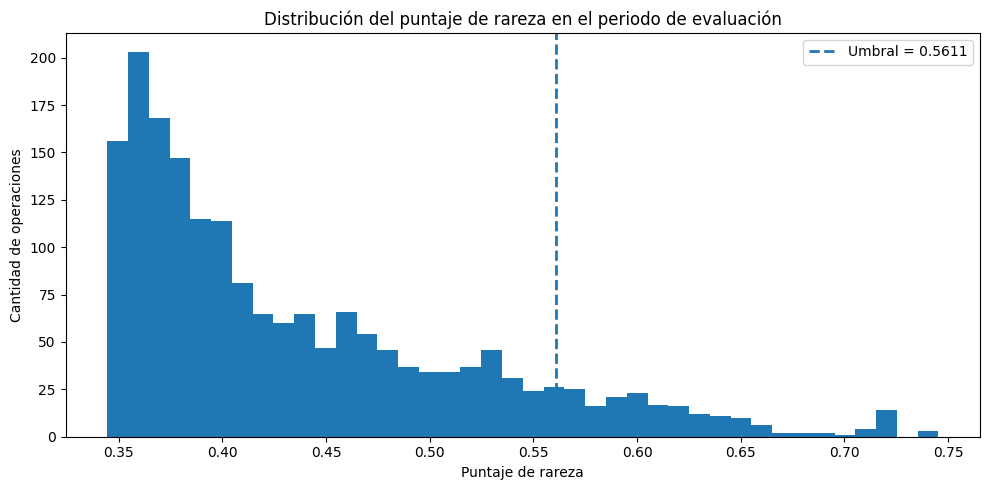

In [13]:
plt.figure(figsize=(10, 5))

plt.hist(
    evaluacion_ia["Puntaje_IA"],
    bins=40
)

plt.axvline(
    umbral_ia,
    linestyle="--",
    linewidth=2,
    label=f"Umbral = {umbral_ia:.4f}"
)

plt.title(
    "Distribución del puntaje de rareza "
    "en el periodo de evaluación"
)
plt.xlabel("Puntaje de rareza")
plt.ylabel("Cantidad de operaciones")
plt.legend()
plt.tight_layout()
plt.show()


## Paso 13. Exportar y descargar los resultados


In [ ]:
nombre_salida = (
    "Resultados_Modelo_Isolation_Forest.xlsx"
)

resumen_validacion = pd.DataFrame({
    "Indicador": [
        "Operaciones históricas",
        "Operaciones evaluadas",
        "Umbral IA",
        "Alertas generadas",
        "Anomalías reales",
        "Anomalías reales detectadas",
        "Falsos positivos",
        "Falsos negativos",
        "Verdaderos negativos",
        "Precisión",
        "Sensibilidad",
        "F1"
    ],
    "Valor": [
        len(X_train),
        len(validacion_ia),
        umbral_ia,
        len(alertas_ia),
        int(y_real.sum()),
        int(tp),
        int(fp),
        int(fn),
        int(tn),
        precision,
        sensibilidad,
        f1
    ]
})

with pd.ExcelWriter(
    nombre_salida,
    engine="openpyxl"
) as writer:

    evaluacion_ia.to_excel(
        writer,
        sheet_name="Resultado_Evaluacion",
        index=False
    )

    alertas_ia.to_excel(
        writer,
        sheet_name="Solo_Alertas",
        index=False
    )

    resumen_motivos_ia.to_excel(
        writer,
        sheet_name="Resumen_Motivos",
        index=False
    )

    resumen_validacion.to_excel(
        writer,
        sheet_name="Resumen_Validacion",
        index=False
    )

    anomalias_detectadas_ia.to_excel(
        writer,
        sheet_name="Anomalias_Detectadas",
        index=False
    )

    falsos_positivos_ia.to_excel(
        writer,
        sheet_name="Falsos_Positivos",
        index=False
    )

    falsos_negativos_ia.to_excel(
        writer,
        sheet_name="Falsos_Negativos",
        index=False
    )

files.download(nombre_salida)

print("Archivo preparado:", nombre_salida)


## Interpretación

Isolation Forest no utiliza reglas individuales para decidir. Aprende la estructura del comportamiento histórico y asigna un puntaje de rareza a cada operación.

La explicación textual resume qué variables contextuales se encuentran más alejadas del historial del socio. Debe presentarse como apoyo para la revisión, no como una explicación causal exacta ni como prueba de fraude.
